# 🔍 Evaluasi Image Retrieval Baseline (Eksperimen 1)

Notebook ini bertujuan untuk mengevaluasi kemampuan pencarian gambar (**Image Retrieval**) dari model *baseline* (ImageNet, tanpa *fine-tuning*).

- **Fitur dimuat dari:** `features/exp1_baseline/`
- **Metrik:** Recall@1, Recall@5, Recall@10, Recall@20, dan mAP (*Mean Average Precision*)
- **Matching:** Berdasarkan kesamaan `item_id` antara gambar *Query* dan gambar *Gallery*.

In [8]:
import os, sys, gc, time
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Path Setup (Auto-Detect Windows Native vs WSL2) ─────────
if sys.platform == 'win32':
    BASE_DIR = r"d:\Antigravity\Visual Based Rekomender Sistem"
    print(f"🪟 Environment terdeteksi: Windows Native ({BASE_DIR})")
else:
    BASE_DIR = '/mnt/d/Antigravity/Visual Based Rekomender Sistem'
    print(f"🐧 Environment terdeteksi: Linux / WSL2 ({BASE_DIR})")

FEAT_DIR = os.path.join(BASE_DIR, 'features', 'exp1_baseline')
FULL_CSV = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'data preperation', 'dataset_output', 'full_dataset.csv')
IMG_DIR  = os.path.join(BASE_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')
EVAL_DIR = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'baseline', 'hasil_evaluasi')

os.makedirs(EVAL_DIR, exist_ok=True)

MODEL_NAMES = ['resnet50', 'vgg19', 'inceptionv3', 'mobilenetv3']
K_VALUES    = [1, 5, 10, 20]
print("✅ Setup path selesai.")

🪟 Environment terdeteksi: Windows Native (d:\Antigravity\Visual Based Rekomender Sistem)
✅ Setup path selesai.


In [9]:
# Load master dataset
df_full = pd.read_csv(FULL_CSV)

# Formasi path gambar
df_full['full_path'] = df_full['image_name'].apply(
    lambda x: os.path.join(IMG_DIR, os.path.normpath(str(x).replace('img/', '', 1)))
)

df_query   = df_full[df_full['split'] == 'query'].reset_index(drop=True)
df_gallery = df_full[df_full['split'] == 'gallery'].reset_index(drop=True)

print("=" * 55)
print("  📊 STATISTIK DATASET RETRIEVAL BASELINE")
print("=" * 55)
print(f"  Total gambar full_dataset  : {len(df_full):,}")
print(f"  Gambar QUERY               : {len(df_query):,}")
print(f"  Gambar GALLERY             : {len(df_gallery):,}")
print(f"  Item unik di QUERY         : {df_query['item_id'].nunique():,}")
print(f"  Item unik di GALLERY       : {df_gallery['item_id'].nunique():,}")
print("=" * 55)

# Overlap check
query_items   = set(df_query['item_id'].unique())
gallery_items = set(df_gallery['item_id'].unique())
overlap = query_items & gallery_items
print(f"  Item ID berpasangan (bisa dievaluasi): {len(overlap):,}")

  📊 STATISTIK DATASET RETRIEVAL BASELINE
  Total gambar full_dataset  : 52,712
  Gambar QUERY               : 14,218
  Gambar GALLERY             : 12,612
  Item unik di QUERY         : 3,985
  Item unik di GALLERY       : 3,985
  Item ID berpasangan (bisa dievaluasi): 3,985


In [10]:
def evaluate_retrieval(query_features, gallery_features, 
                       query_item_ids, gallery_item_ids, 
                       k_values=[1, 5, 10, 20]):
    """
    Evaluasi retrieval: Cosine similarity antara query & gallery
    Hitung Recall@K dan mAP.
    """
    n_queries = len(query_features)
    similarity_matrix = query_features @ gallery_features.T

    recall_at_k = {k: 0 for k in k_values}
    average_precisions = []

    for i in tqdm(range(n_queries), desc="Evaluating Queries"):
        query_id = query_item_ids[i]
        gt_mask = (gallery_item_ids == query_id)
        n_relevant = gt_mask.sum()

        if n_relevant == 0:
            continue

        sorted_indices = np.argsort(-similarity_matrix[i])

        for k in k_values:
            top_k_indices = sorted_indices[:k]
            top_k_ids = gallery_item_ids[top_k_indices]
            if query_id in top_k_ids:
                recall_at_k[k] += 1

        ap = 0.0
        n_correct = 0
        for rank, idx in enumerate(sorted_indices):
            if gt_mask[idx]:
                n_correct += 1
                ap += n_correct / (rank + 1)
        ap /= n_relevant
        average_precisions.append(ap)

    n_evaluated = len(average_precisions)
    results = {}
    for k in k_values:
        results[f'Recall@{k}'] = recall_at_k[k] / n_evaluated if n_evaluated > 0 else 0.0

    results['mAP'] = float(np.mean(average_precisions)) if average_precisions else 0.0
    results['n_queries_evaluated'] = n_evaluated
    return results

print("✅ Fungsi evaluasi siap.")

✅ Fungsi evaluasi siap.


In [11]:
print("=" * 65)
print("  📊 JALANKAN EVALUASI RETRIEVAL BASELINE (ImageNet)")
print("=" * 65)

all_results = {}

for model_name in MODEL_NAMES:
    print(f"\n🧠 Evaluating Baseline: {model_name.upper()}")

    q_feat_path = os.path.join(FEAT_DIR, f'{model_name}_query_features.npy')
    g_feat_path = os.path.join(FEAT_DIR, f'{model_name}_gallery_features.npy')
    q_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_query_valid_idx.npy')
    g_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_gallery_valid_idx.npy')

    if not (os.path.exists(q_feat_path) and os.path.exists(g_feat_path)):
        print(f"  ⚠️ File fitur tidak ditemukan untuk {model_name}, skip!")
        continue

    q_feats = np.load(q_feat_path)
    g_feats = np.load(g_feat_path)
    q_valid = np.load(q_idx_path)
    g_valid = np.load(g_idx_path)

    q_item_ids = df_query.iloc[q_valid]['item_id'].values
    g_item_ids = df_gallery.iloc[g_valid]['item_id'].values

    res = evaluate_retrieval(q_feats, g_feats, q_item_ids, g_item_ids, k_values=K_VALUES)
    all_results[model_name] = res

    print(f"  Recall@1:  {res['Recall@1']:.4f}")
    print(f"  Recall@5:  {res['Recall@5']:.4f}")
    print(f"  Recall@10: {res['Recall@10']:.4f}")
    print(f"  Recall@20: {res['Recall@20']:.4f}")
    print(f"  mAP:       {res['mAP']:.4f}")

  📊 JALANKAN EVALUASI RETRIEVAL BASELINE (ImageNet)

🧠 Evaluating Baseline: RESNET50


Evaluating Queries: 100%|██████████| 14218/14218 [00:32<00:00, 444.12it/s]


  Recall@1:  0.2946
  Recall@5:  0.4605
  Recall@10: 0.5282
  Recall@20: 0.5978
  mAP:       0.1555

🧠 Evaluating Baseline: VGG19


Evaluating Queries: 100%|██████████| 14218/14218 [00:31<00:00, 448.77it/s]


  Recall@1:  0.2244
  Recall@5:  0.3710
  Recall@10: 0.4354
  Recall@20: 0.5043
  mAP:       0.1137

🧠 Evaluating Baseline: INCEPTIONV3


Evaluating Queries: 100%|██████████| 14218/14218 [00:31<00:00, 449.89it/s]


  Recall@1:  0.2673
  Recall@5:  0.4352
  Recall@10: 0.5068
  Recall@20: 0.5801
  mAP:       0.1433

🧠 Evaluating Baseline: MOBILENETV3


Evaluating Queries: 100%|██████████| 14218/14218 [00:31<00:00, 449.11it/s]

  Recall@1:  0.3389
  Recall@5:  0.5186
  Recall@10: 0.5969
  Recall@20: 0.6677
  mAP:       0.1944


In [12]:
# Tampilkan Tabel Perbandingan & Simpan ke CSV
df_results = pd.DataFrame(all_results).T
n_eval = df_results['n_queries_evaluated'].iloc[0] if len(df_results) > 0 else 0
df_results = df_results.drop(columns=['n_queries_evaluated'])

print("\n" + "=" * 75)
print("  📊 TABEL HASIL EVALUASI RETRIEVAL BASELINE (ImageNet)")
print("=" * 75)
print(df_results.to_string())
print("=" * 75)

# Simpan CSV Hasil
csv_out = os.path.join(EVAL_DIR, 'retrieval_evaluation_baseline.csv')
df_results.to_csv(csv_out)
print(f"\n💾 Hasil evaluasi berhasil disimpan ke:\n   {csv_out}")


  📊 TABEL HASIL EVALUASI RETRIEVAL BASELINE (ImageNet)
             Recall@1  Recall@5  Recall@10  Recall@20       mAP
resnet50     0.294556  0.460473   0.528204   0.597763  0.155451
vgg19        0.224363  0.371009   0.435364   0.504290  0.113654
inceptionv3  0.267337  0.435223   0.506822   0.580110  0.143262
mobilenetv3  0.338866  0.518568   0.596919   0.667745  0.194441

💾 Hasil evaluasi berhasil disimpan ke:
   d:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\baseline\hasil_evaluasi\retrieval_evaluation_baseline.csv


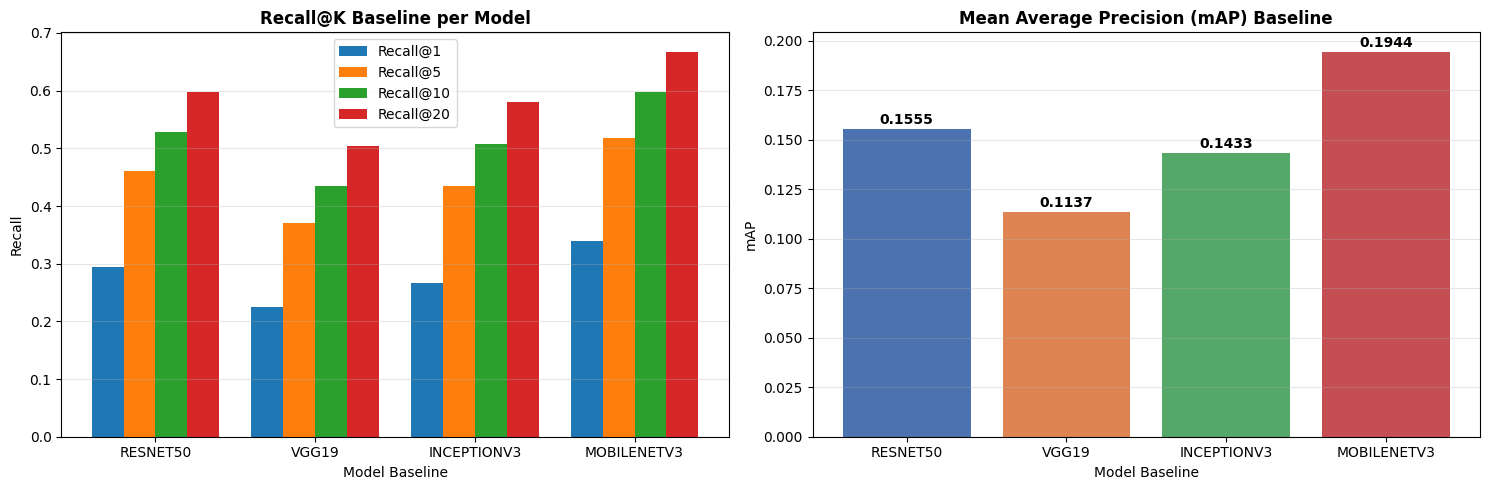

✅ Chart disimpan ke: d:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\baseline\hasil_evaluasi\retrieval_baseline_chart.png


In [13]:
# Visualisasi Bar Chart Perbandingan Model
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models = list(all_results.keys())
x = np.arange(len(models))
width = 0.2

for i, k in enumerate(K_VALUES):
    values = [all_results[m][f'Recall@{k}'] for m in models]
    axes[0].bar(x + i * width, values, width, label=f'Recall@{k}')

axes[0].set_xlabel('Model Baseline')
axes[0].set_ylabel('Recall')
axes[0].set_title('Recall@K Baseline per Model', fontweight='bold')
axes[0].set_xticks(x + 1.5 * width)
axes[0].set_xticklabels([m.upper() for m in models])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot mAP
map_vals = [all_results[m]['mAP'] for m in models]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = axes[1].bar([m.upper() for m in models], map_vals, color=colors)
axes[1].set_xlabel('Model Baseline')
axes[1].set_ylabel('mAP')
axes[1].set_title('Mean Average Precision (mAP) Baseline', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, map_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
chart_out = os.path.join(EVAL_DIR, 'retrieval_baseline_chart.png')
plt.savefig(chart_out, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart disimpan ke: {chart_out}")

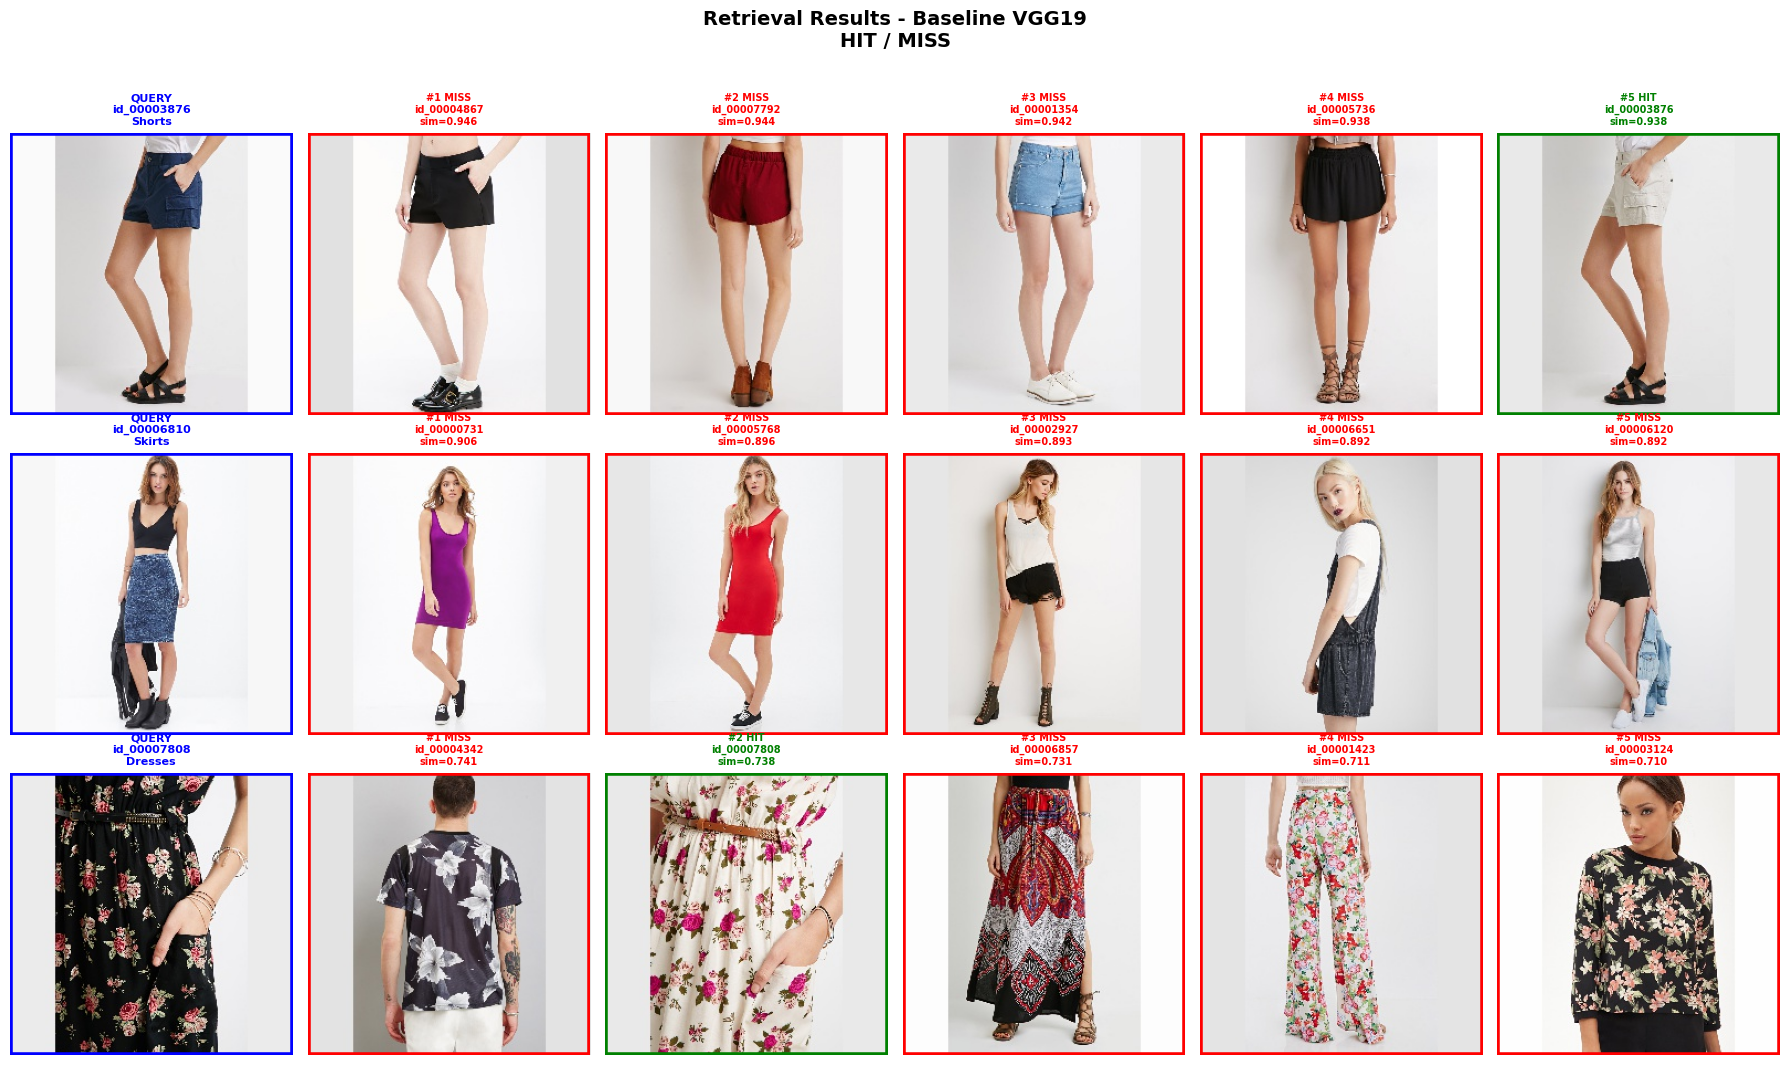

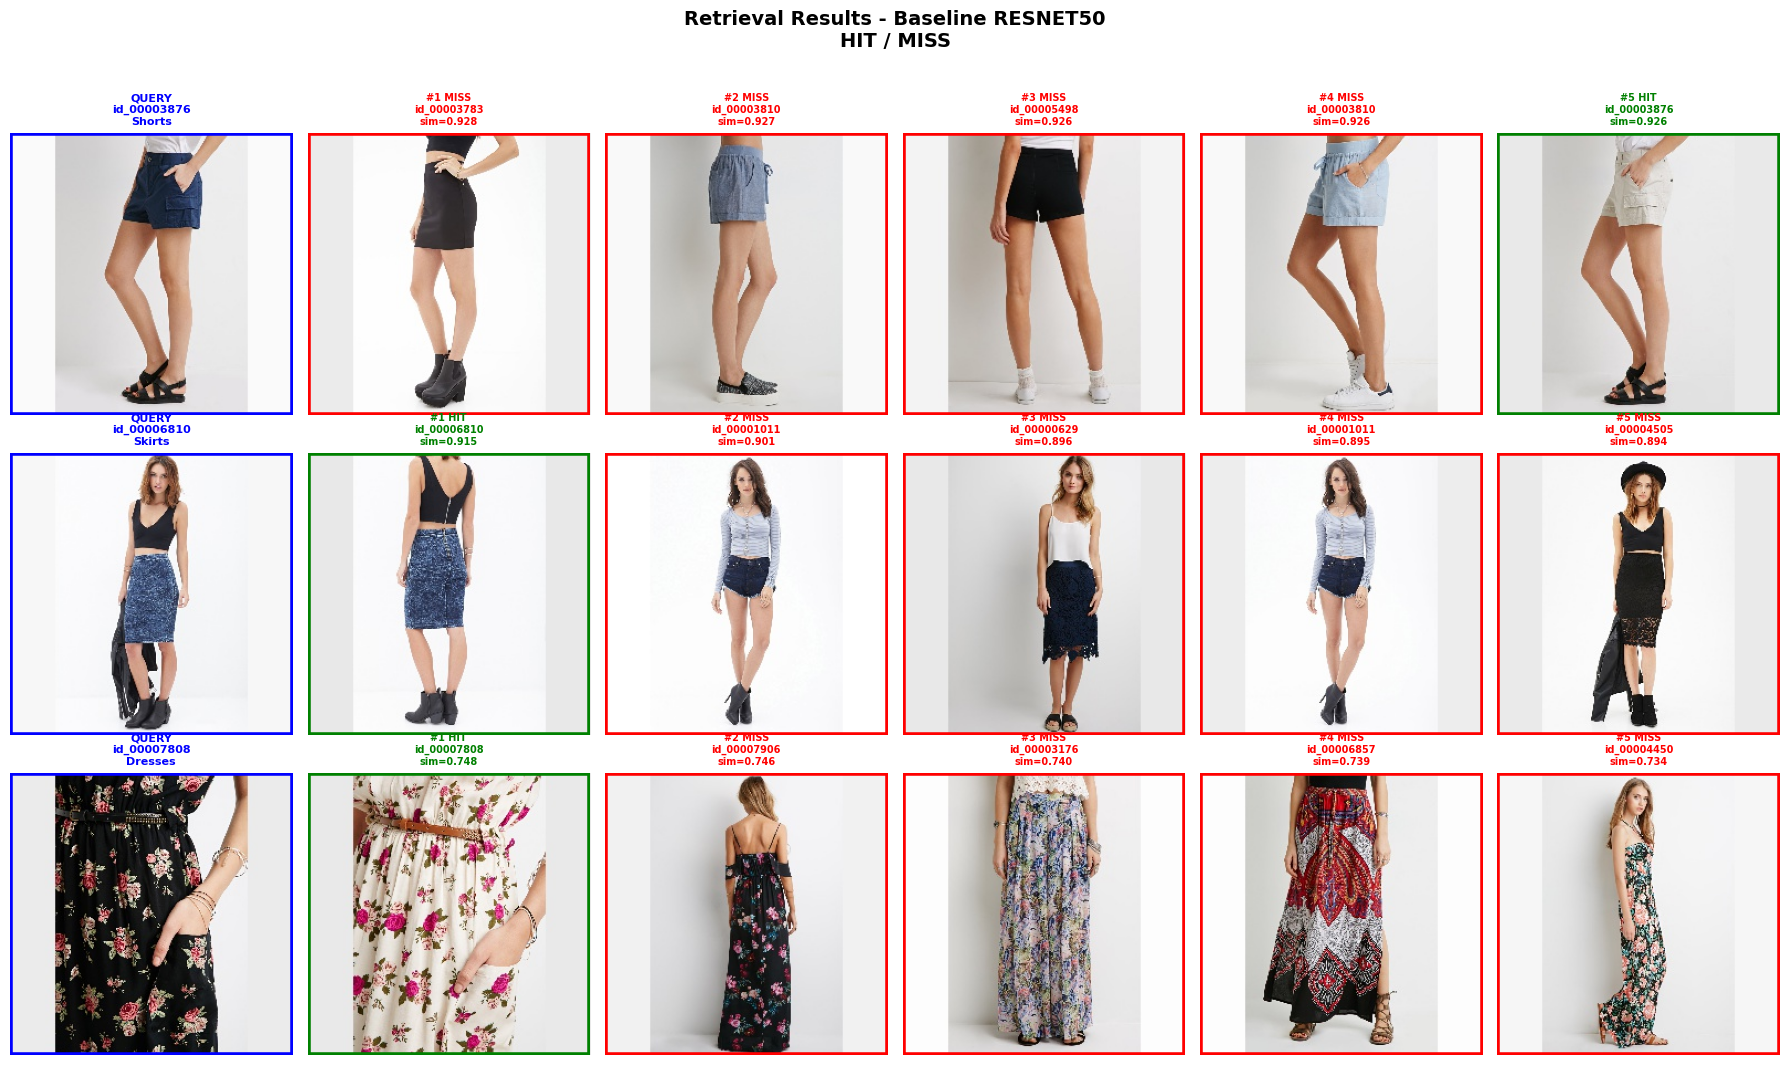

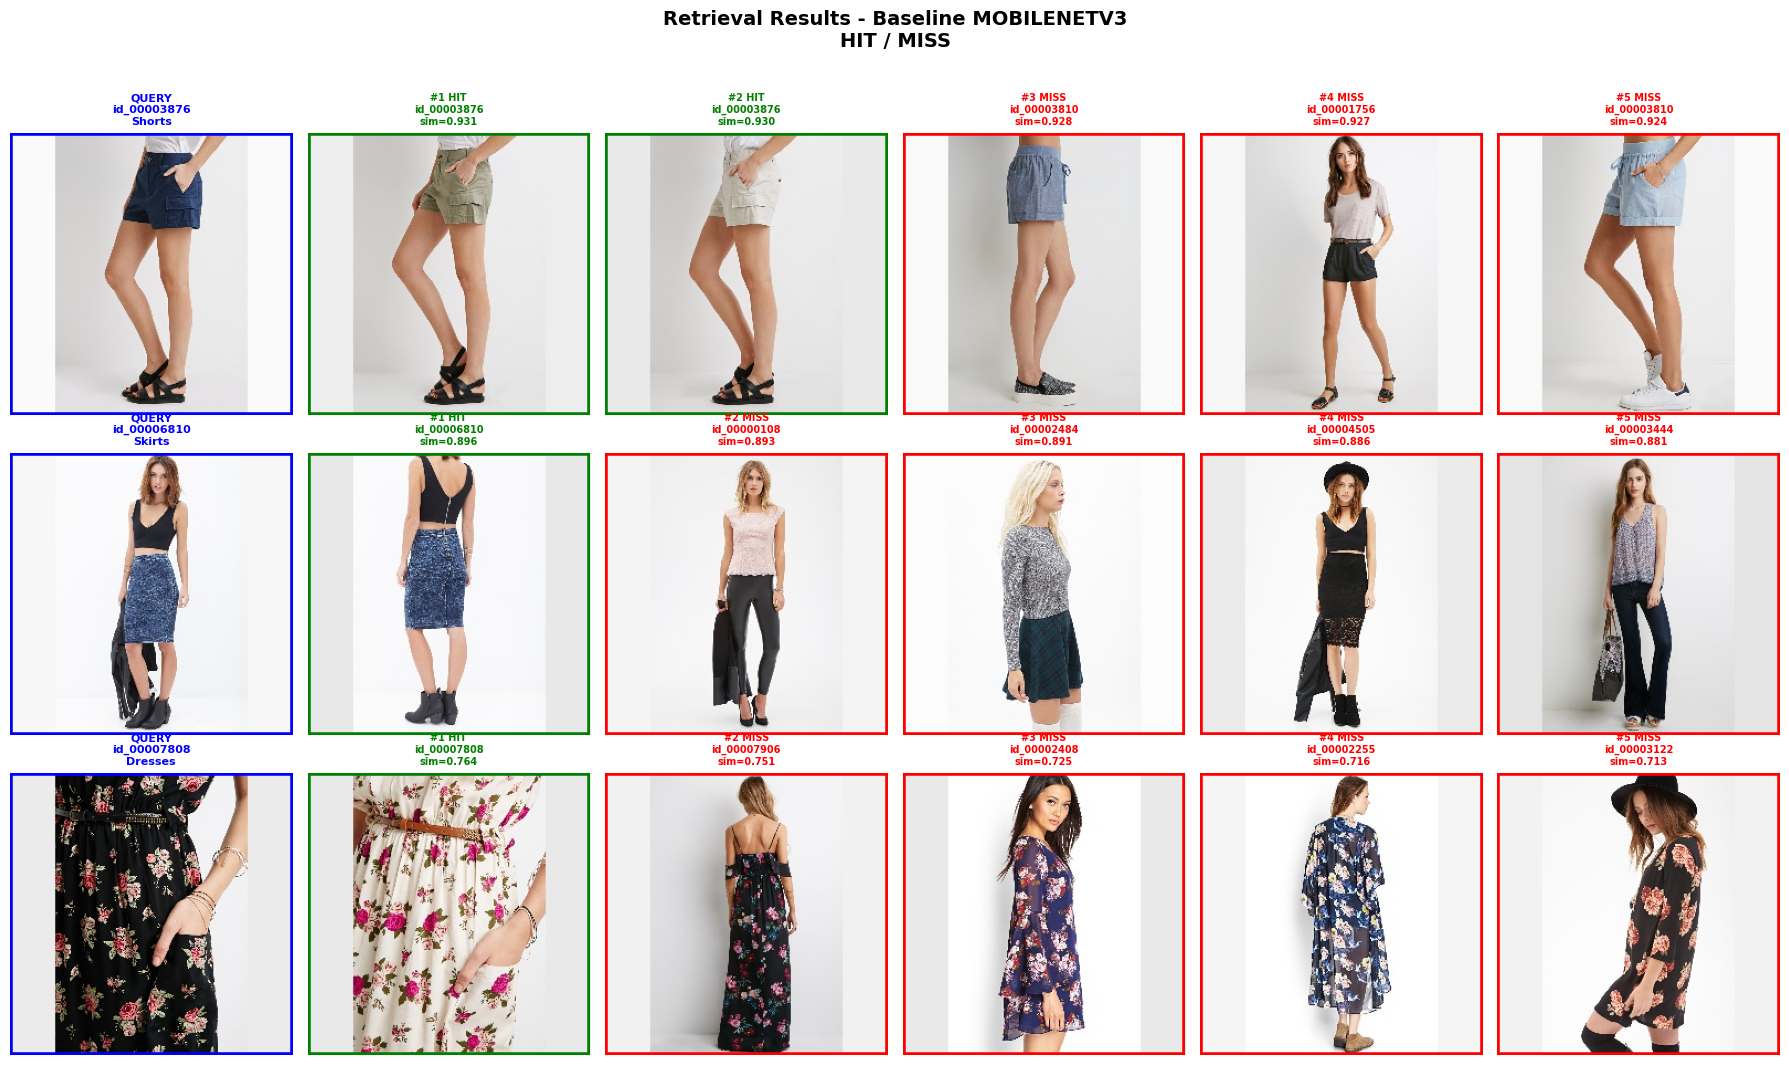

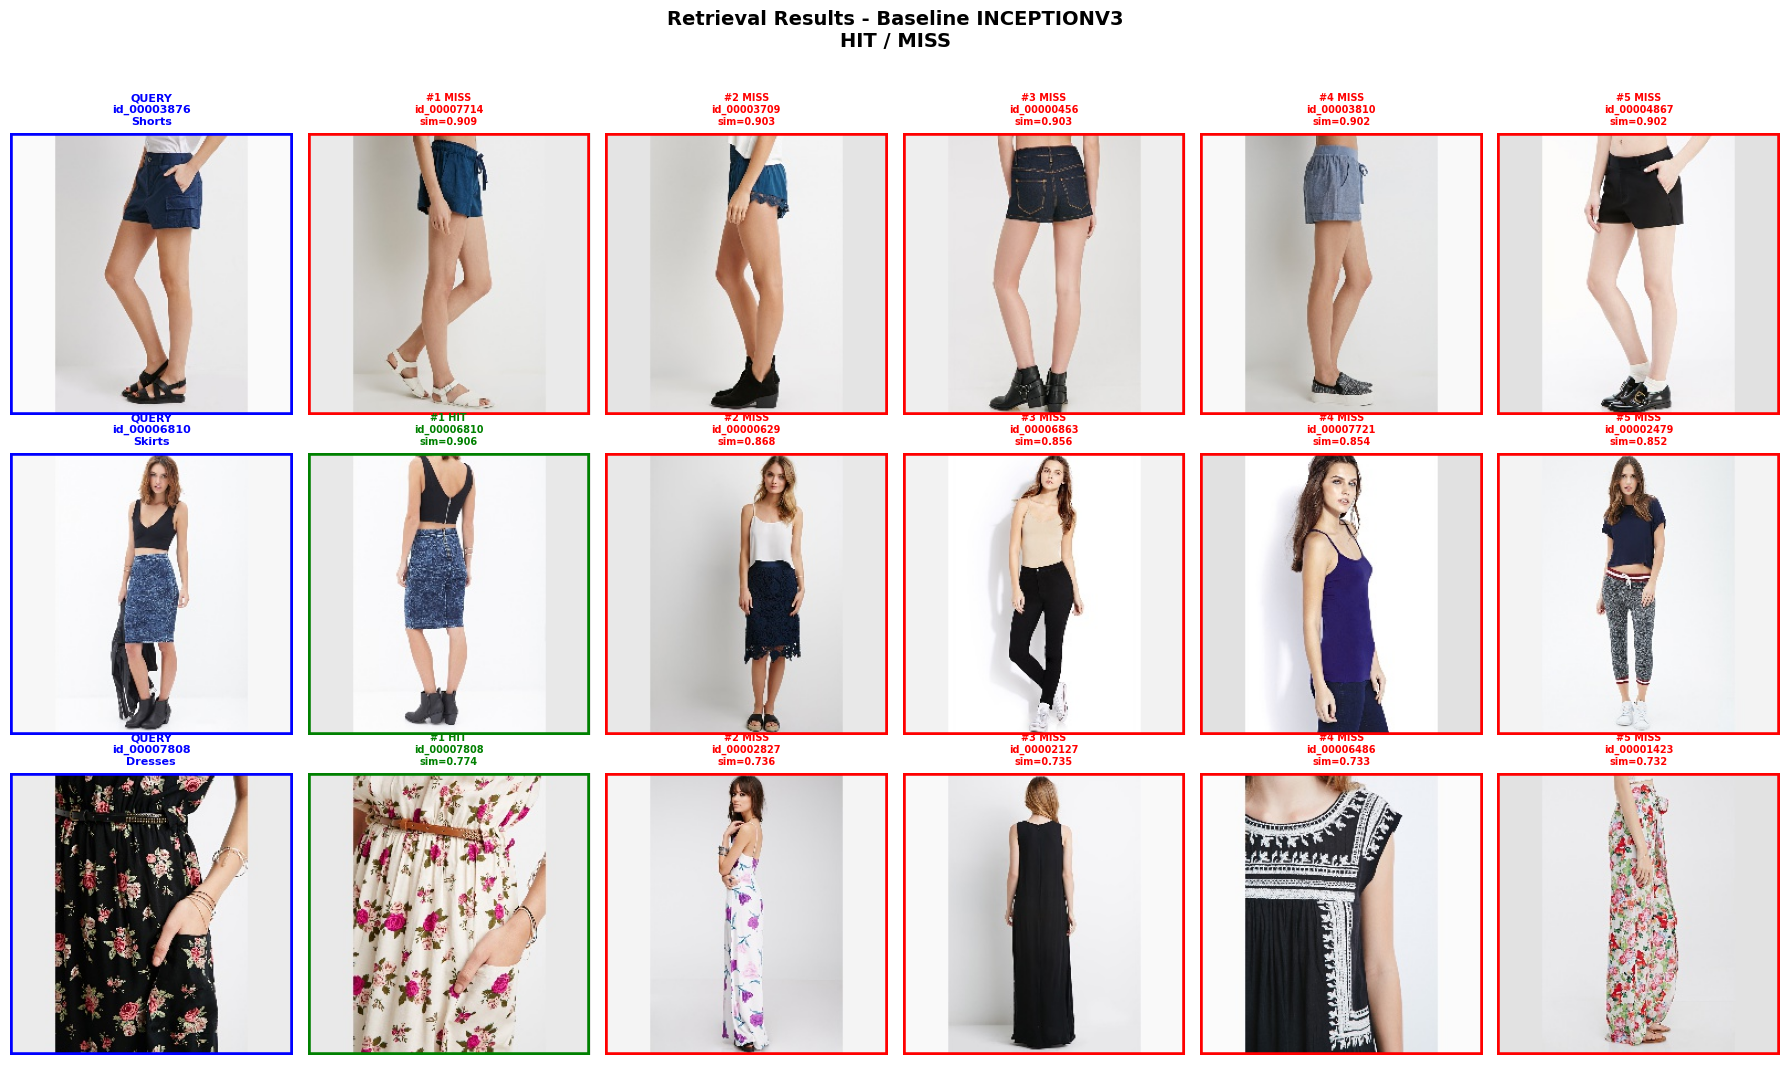

In [15]:
# Visualisasi Kualitatif: Sample Query vs Top-5 Gallery Results
def visualize_sample_retrieval(model_name, df_query, df_gallery, n_samples=3, top_k=5, seed=42):
    q_feat_path = os.path.join(FEAT_DIR, f'{model_name}_query_features.npy')
    g_feat_path = os.path.join(FEAT_DIR, f'{model_name}_gallery_features.npy')
    q_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_query_valid_idx.npy')
    g_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_gallery_valid_idx.npy')

    if not os.path.exists(q_feat_path):
        return

    q_feats = np.load(q_feat_path)
    g_feats = np.load(g_feat_path)
    q_valid = np.load(q_idx_path)
    g_valid = np.load(g_idx_path)

    q_item_ids = df_query.iloc[q_valid]['item_id'].values
    g_item_ids = df_gallery.iloc[g_valid]['item_id'].values

    sim_matrix = q_feats @ g_feats.T
    np.random.seed(seed)
    sample_indices = np.random.choice(len(q_feats), size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, top_k + 1, figsize=(3 * (top_k + 1), 3.5 * n_samples))
    title_text = "Retrieval Results - Baseline " + model_name.upper() + "\nHIT / MISS"
    fig.suptitle(title_text, fontsize=14, fontweight='bold', y=1.02)

    for row, q_idx in enumerate(sample_indices):
        query_id = q_item_ids[q_idx]
        query_row = df_query.iloc[q_valid[q_idx]]

        # Plot Query
        ax = axes[row, 0]
        try:
            img = Image.open(query_row['full_path']).convert('RGB')
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        q_cat = str(query_row.get('category', ''))
        ax.set_title(f"QUERY\n{query_id}\n{q_cat}", fontsize=8, color='blue', fontweight='bold')
        ax.axis('off')
        rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes, linewidth=4, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)

        # Top-K Gallery
        sorted_g_idx = np.argsort(-sim_matrix[q_idx])[:top_k]
        for col, g_rank_idx in enumerate(sorted_g_idx):
            ax = axes[row, col + 1]
            gallery_id = g_item_ids[g_rank_idx]
            gallery_row = df_gallery.iloc[g_valid[g_rank_idx]]
            sim_score = sim_matrix[q_idx, g_rank_idx]
            is_hit = (gallery_id == query_id)

            try:
                img = Image.open(gallery_row['full_path']).convert('RGB')
                ax.imshow(img)
            except:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center')

            status = "HIT" if is_hit else "MISS"
            color = 'green' if is_hit else 'red'
            ax.set_title(f"#{col+1} {status}\n{gallery_id}\nsim={sim_score:.3f}", fontsize=7, color=color, fontweight='bold')
            ax.axis('off')
            rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes, linewidth=4, edgecolor=color, facecolor='none')
            ax.add_patch(rect)

    plt.tight_layout()
    vis_out = os.path.join(EVAL_DIR, f'retrieval_visual_{model_name}_baseline.png')
    plt.savefig(vis_out, dpi=150, bbox_inches='tight')
    plt.show()

# Contoh visualisasi VGG19 dan ResNet50
visualize_sample_retrieval('vgg19', df_query, df_gallery, n_samples=3, top_k=5)
visualize_sample_retrieval('resnet50', df_query, df_gallery, n_samples=3, top_k=5)
visualize_sample_retrieval('mobilenetv3', df_query, df_gallery, n_samples=3, top_k=5)
visualize_sample_retrieval('inceptionv3', df_query, df_gallery, n_samples=3, top_k=5)